In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False

def extract_best_metric(metrics_file, metric_name, mode='max'):
    """从metrics.csv中提取指定指标的最佳值"""
    try:
        df = pd.read_csv(metrics_file)
        
        # 1. 判断 metric_name 是否可以作为数字索引
        is_numeric_index = False
        try:
            col_idx = int(metric_name)
            is_numeric_index = True
        except (ValueError, TypeError):
            pass # 转换失败，说明是普通字符串
            
        # 2. 提取目标列 (Target Series)
        if is_numeric_index:
            # 检查索引是否越界
            if col_idx >= len(df.columns) or col_idx < -len(df.columns):
                return None
            target_series = df.iloc[:, col_idx]
        else:
            # 🌟 [核心修改] 遍历列名，进行子串查找
            matched_col = None
            for col in df.columns:
                if str(metric_name) in str(col):
                    matched_col = col
                    break  # 找到第一个包含该子串的列就停止
            
            # 如果遍历完都没找到包含该子串的列，则返回 None
            if matched_col is None:
                return None
                
            target_series = df[matched_col]

        # 3. 清洗数据并确保其为数值型
        clean_series = pd.to_numeric(target_series, errors='coerce') 
        clean_series = clean_series.replace([np.inf, -np.inf], np.nan).dropna()
        
        if clean_series.empty:
            return None
            
        # 4. 返回最值
        return clean_series.max() if mode == 'max' else clean_series.min()
        
    except Exception as e:
        # print(f"Error: {e}") # 调试时可以解开
        return None

def scan_experiments(root_dir, target_metric='Avg_sMAPE_Imp', mode='max', target_hash=None):
    """
    target_hash: (str) 指定要搜索的哈希字符串，如 '162d17c6'。如果不为 None，则只处理目录名包含该字符串的实验。
    """
    records = []
    print(f"Scanning directory: {root_dir}")
    if target_hash:
        print(f"Filter enabled: Searching ONLY for experiments matching hash '{target_hash}'...")
    
    for root, dirs, files in os.walk(root_dir):
        # 1. 快速过滤：检查是否为有效的实验目录（必须包含 metric 和 param 文件）
        if 'metrics.csv' in files and 'hyperparams.json' in files:
            
            # 获取当前目录名（通常为 run_000_xxxxx）
            current_run_id = os.path.basename(root)
            
            # 2. 哈希匹配：如果在过滤模式下，且当前目录名不包含目标哈希，直接跳过
            if target_hash and (str(target_hash) not in current_run_id):
                continue
            
            # 3. 开始处理命中实验
            metrics_path = os.path.join(root, 'metrics.csv')
            params_path = os.path.join(root, 'hyperparams.json')
            
            # 提取指标
            best_val = extract_best_metric(metrics_path, target_metric, mode)
            if best_val is None: continue 
            
            # 读取参数
            try:
                with open(params_path, 'r', encoding='utf-8') as f:
                    params = json.load(f)
            except:
                params = {}

            # 解析路径层级: TSFM/Encoder/Corrector/RunID
            rel_path = os.path.relpath(root, root_dir)
            path_parts = rel_path.split(os.sep)
            
            tsfm_name = path_parts[0] if len(path_parts) >= 1 else params.get('target_tsfm', 'Unknown')
            encoder_name = path_parts[1] if len(path_parts) >= 2 else params.get('encoder_type', 'Unknown')
            corrector_name = path_parts[2] if len(path_parts) >= 3 else params.get('corrector_arch', 'Unknown')
            
            records.append({
                'Experiment_ID': current_run_id,
                'TSFM': tsfm_name,
                'Encoder': encoder_name,
                'Corrector': corrector_name,
                'Metric_Name': target_metric,
                'Performance': best_val,
                'Learning_Rate': params.get('learning_rate', 'N/A'), # 示例：提取学习率
                'Batch_Size': params.get('batch_size', 'N/A'),       # 示例：提取batch size
                'Path': rel_path
            })
            
    print(f"Done. Found {len(records)} matching experiments.")
    return pd.DataFrame(records)

In [2]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False

def plot_quantile_trends_by_hash(root_dir, hash_code, target_metric="sMAPE"):
    """
    通过穿透递归搜索，将指定哈希码下各个 Corrector 的实验都绘制出来。
    右侧信息栏汇总各个 TSFM 的最佳分位数与最高提升。
    """
    print(f"Scanning directory: {root_dir}")
    print(f"Filter enabled: Searching ONLY for experiments matching hash '{hash_code}'...")
    
    # 1. 扫描并按 Corrector 分组汇总所有 metrics.csv 的路径
    corrector_groups = defaultdict(list)
    
    for root, dirs, files in os.walk(root_dir):
        if 'metrics.csv' in files and 'hyperparams.json' in files:
            current_run_id = os.path.basename(root)
            
            # 哈希匹配
            if hash_code and (str(hash_code) not in current_run_id):
                continue
                
            metrics_path = os.path.join(root, 'metrics.csv')
            params_path = os.path.join(root, 'hyperparams.json')
            
            try:
                with open(params_path, 'r', encoding='utf-8') as f:
                    params = json.load(f)
            except:
                params = {}
                
            rel_path = os.path.relpath(root, root_dir)
            path_parts = rel_path.split(os.sep)
            
            # 提取 Corrector 名称
            corrector_name = path_parts[2] if len(path_parts) >= 3 else params.get('corrector_arch', 'Unknown')
            corrector_groups[corrector_name].append(metrics_path)
            
    if not corrector_groups:
        print(f"❌ 未找到包含哈希码 '{hash_code}' 的有效实验数据！请检查路径和哈希码。")
        return
        
    print(f"🔍 成功找到匹配的实验，涵盖 {len(corrector_groups)} 个 Corrector 架构。开始绘图...\n")
    
    col_pattern = re.compile(rf'^(.*)_{target_metric}_Imp_Top([\d\.]+)$')
    
    # 2. 按 Corrector 进行聚合并绘图
    for corrector_name, metrics_paths in corrector_groups.items():
        tsfm_data = defaultdict(dict)
        
        for m_path in metrics_paths:
            try:
                df = pd.read_csv(m_path)
            except Exception as e:
                print(f"读取 {m_path} 失败: {e}")
                continue
                
            for col in df.columns:
                match = col_pattern.match(col)
                if match:
                    tsfm = match.group(1)
                    if tsfm.lower() == "avg": 
                        continue
                    q_val = float(match.group(2))
                    
                    clean_series = pd.to_numeric(df[col], errors='coerce').dropna()
                    if not clean_series.empty:
                        current_max = clean_series.max()
                        if q_val in tsfm_data[tsfm]:
                            tsfm_data[tsfm][q_val] = max(tsfm_data[tsfm][q_val], current_max)
                        else:
                            tsfm_data[tsfm][q_val] = current_max
        
        if not tsfm_data:
            print(f"⚠️ Corrector [{corrector_name}] 下未找到符合 '{target_metric}_Imp_Top' 格式的列，已跳过。")
            continue
            
        # ==================== 开始绘图 ====================
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = sns.color_palette("husl", len(tsfm_data))
        
        summary_lines = ["🏆 最佳阈值总结 (Best Thresholds):"]
        
        for idx, (tsfm, q_dict) in enumerate(tsfm_data.items()):
            sorted_qs = sorted(q_dict.keys())
            imps = [q_dict[q] for q in sorted_qs]
            
            max_imp = max(imps)
            best_q = sorted_qs[imps.index(max_imp)]
            
            # 记录到总结文本中
            summary_lines.append(f"• {tsfm}:\n   {max_imp:+.2f}%  (Top {best_q}%)")
            
            # 仅绘制折线，不再添加 annotate
            ax.plot(sorted_qs, imps, marker='o', linewidth=2, markersize=6, 
                     color=colors[idx], label=tsfm)

        # 标题与装饰
        ax.set_title(f"Performance Trend by Difficulty Percentiles\nCorrector: {corrector_name} (Hash: {hash_code})", fontsize=14, pad=15)
        ax.set_xlabel("Tested Percentile (Top X% Hardest Samples)", fontsize=12)
        ax.set_ylabel(f"Max {target_metric} Improvement (%)", fontsize=12)
        
        min_q = min([min(q.keys()) for q in tsfm_data.values()])
        ax.set_xlim(max(0, min_q - 5), 105)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
        
        # 将图例放置在右侧外部
        ax.legend(title="Target TSFM", bbox_to_anchor=(1.02, 1), loc='upper left')
        
        # 在图例下方放置右侧总结面板
        summary_text = "\n".join(summary_lines)
        ax.text(1.02, 0.65, summary_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top', linespacing=1.6,
                bbox=dict(boxstyle='round,pad=0.6', fc='#f8f9fa', ec='lightgray', alpha=0.9))
        
        # 压缩绘图主区域，为右侧图例和总结文本预留空间
        plt.subplots_adjust(right=0.72)
        plt.show()


In [15]:
# ================= 配置区 =================
ROOT_DIR = r"results\dual_source_experiment_0331_V2" 
TARGET_METRIC = '-1' 
METRIC_MODE = 'max' 

# [NEW] 指定特定哈希码 (设为 None 则扫描所有)
# 例如: '162d17c6' 或 'run_000_162d17c6'
TARGET_HASH_FILTER = 'run_001_5b385438'# run_001_39f09f4e  162d17c6
# ==========================================

# 运行扫描
df_results = scan_experiments(
    ROOT_DIR, 
    target_metric=TARGET_METRIC, 
    mode=METRIC_MODE, 
    target_hash=TARGET_HASH_FILTER
)

# 展示结果
if not df_results.empty:
    print("\n=== Matched Experiment Details ===")
    # 强制显示所有列，防止被省略
    pd.set_option('display.max_columns', None)
    display(df_results)
else:
    print(f"No experiments found matching hash: {TARGET_HASH_FILTER}")

Scanning directory: results\dual_source_experiment_0331_V2
Filter enabled: Searching ONLY for experiments matching hash 'run_001_5b385438'...
Done. Found 15 matching experiments.

=== Matched Experiment Details ===


,Experiment_ID,TSFM,Encoder,Corrector,Metric_Name,Performance,Learning_Rate,Batch_Size,Path
0,run_001_5b385438,chronos_bolt_tiny,advanced_hybrid_math,dual_fusion_V2,-1,0.000339,0.01,256,chronos_bolt_tiny\advanced_hybrid_math\dual_fu...
1,run_001_5b385438,chronos_bolt_tiny,advanced_hybrid_math,dual_latent_cross_attn,-1,-0.196803,0.01,256,chronos_bolt_tiny\advanced_hybrid_math\dual_la...
2,run_001_5b385438,chronos_bolt_tiny,advanced_hybrid_math,mean_retrieval,-1,1.937488,0.01,256,chronos_bolt_tiny\advanced_hybrid_math\mean_re...
3,run_001_5b385438,kairos_10m,advanced_hybrid_math,dual_fusion_V2,-1,13.259629,0.01,256,kairos_10m\advanced_hybrid_math\dual_fusion_V2...
4,run_001_5b385438,kairos_10m,advanced_hybrid_math,dual_latent_cross_attn,-1,15.465024,0.01,256,kairos_10m\advanced_hybrid_math\dual_latent_cr...
5,run_001_5b385438,kairos_10m,advanced_hybrid_math,mean_retrieval,-1,15.383676,0.01,256,kairos_10m\advanced_hybrid_math\mean_retrieval...
6,run_001_5b385438,moirai_small,advanced_hybrid_math,dual_fusion_V2,-1,0.994649,0.01,256,moirai_small\advanced_hybrid_math\dual_fusion_...
7,run_001_5b385438,moirai_small,advanced_hybrid_math,dual_latent_cross_attn,-1,4.193494,0.01,256,moirai_small\advanced_hybrid_math\dual_latent_...
8,run_001_5b385438,moirai_small,advanced_hybrid_math,mean_retrieval,-1,7.270302,0.01,256,moirai_small\advanced_hybrid_math\mean_retriev...
9,run_001_5b385438,timesfm_2.5,advanced_hybrid_math,dual_fusion_V2,-1,0.001876,0.01,256,timesfm_2.5\advanced_hybrid_math\dual_fusion_V...


In [16]:
if len(df_results) == 1:
    # 如果只找到了一个实验，直接绘制其训练曲线
    target_path = os.path.join(ROOT_DIR, df_results.iloc[0]['Path'], 'metrics.csv')
    
    try:
        df_metric = pd.read_csv(target_path)
        
        plt.figure(figsize=(12, 5))
        
        # 绘制 Loss
        plt.subplot(1, 2, 1)
        if 'Train_Loss' in df_metric.columns:
            plt.plot(df_metric['Epoch'], df_metric['Train_Loss'], label='Train Loss')
            plt.title(f"Loss Curve ({df_results.iloc[0]['Experiment_ID']})")
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
        
        # 绘制 Target Metric
        plt.subplot(1, 2, 2)
        if TARGET_METRIC in df_metric.columns:
            plt.plot(df_metric['Epoch'], df_metric[TARGET_METRIC], color='orange', label=TARGET_METRIC)
            plt.title(f"Performance: {TARGET_METRIC}")
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.legend()
            
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Could not plot metrics: {e}")


=== Performance Pivot Table (-1) ===


Corrector,dual_fusion_V2,dual_latent_cross_attn,mean_retrieval
TSFM,,,
chronos_bolt_tiny,0.000339,-0.196803,1.937488
kairos_10m,13.259629,15.465024,15.383676
moirai_small,0.994649,4.193494,7.270302
timesfm_2.5,0.001876,-0.181887,0.004344
tirex_base,-0.012541,-0.610060,-0.073973


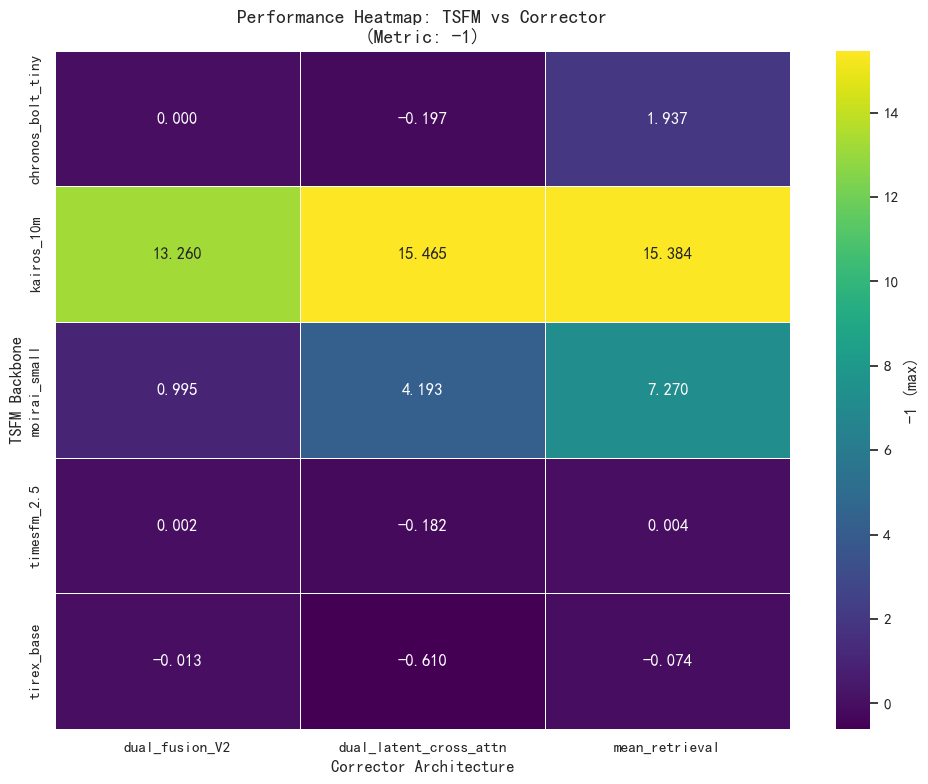

In [17]:
if not df_results.empty:
    # 1. 创建透视表
    # aggfunc='mean' 计算平均性能，也可以改为 'max' 查看该组合下的最佳性能
    pivot_table = df_results.pivot_table(
        index='TSFM', 
        columns='Corrector', 
        values='Performance', 
        aggfunc='mean' 
    )

    print(f"\n=== Performance Pivot Table ({TARGET_METRIC}) ===")
    display(pivot_table)

    # 2. 绘制热力图
    plt.figure(figsize=(10, 8))
    
    # 自动调整颜色映射范围
    vmin = df_results['Performance'].min()
    vmax = df_results['Performance'].max()
    
    heatmap = sns.heatmap(
        pivot_table, 
        annot=True,         # 显示数值
        fmt=".3f",          # 保留3位小数
        cmap="viridis",     # 颜色主题 (可选: 'coolwarm', 'RdBu_r', 'magma')
        linewidths=.5, 
        cbar_kws={'label': f'{TARGET_METRIC} ({METRIC_MODE})'}
    )
    
    plt.title(f'Performance Heatmap: TSFM vs Corrector\n(Metric: {TARGET_METRIC})', fontsize=14)
    plt.ylabel('TSFM Backbone', fontsize=12)
    plt.xlabel('Corrector Architecture', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("No data available to visualize.")

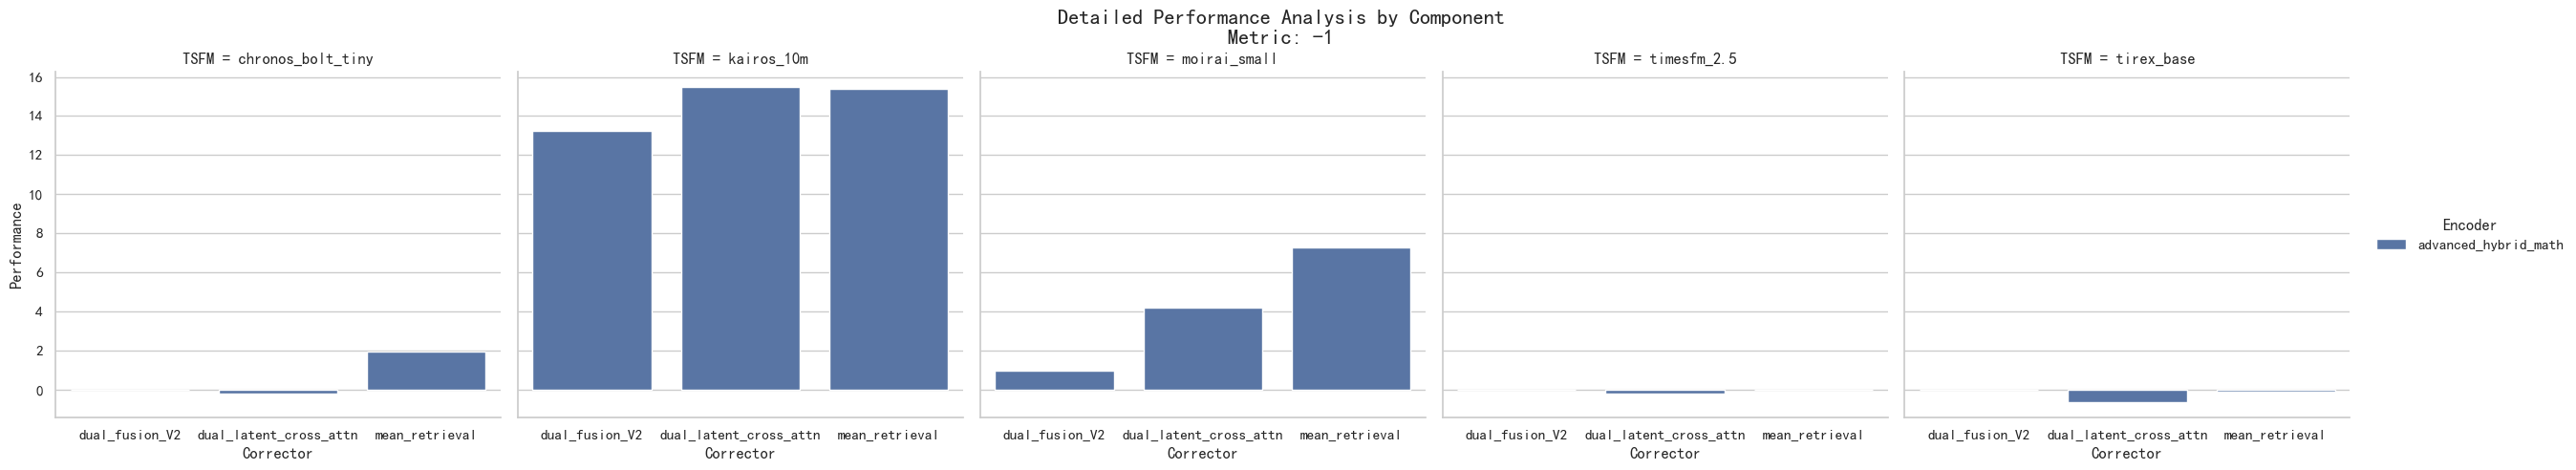

In [18]:
if not df_results.empty:
    g = sns.catplot(
        data=df_results, 
        x="Corrector", 
        y="Performance", 
        hue="Encoder",       # 颜色区分 Encoder
        col="TSFM",          # 分栏显示不同的 TSFM
        kind="bar",          # 柱状图
        height=5, 
        aspect=1,
        sharey=True          # 共享 Y 轴刻度以便对比
    )
    
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f'Detailed Performance Analysis by Component\nMetric: {TARGET_METRIC}', fontsize=16)
    plt.show()


=== Performance Pivot Table (-1) ===


Encoder,advanced_hybrid_math
TSFM,
chronos_bolt_tiny,0.580341
kairos_10m,14.702776
moirai_small,4.152815
timesfm_2.5,-0.058556
tirex_base,-0.232191


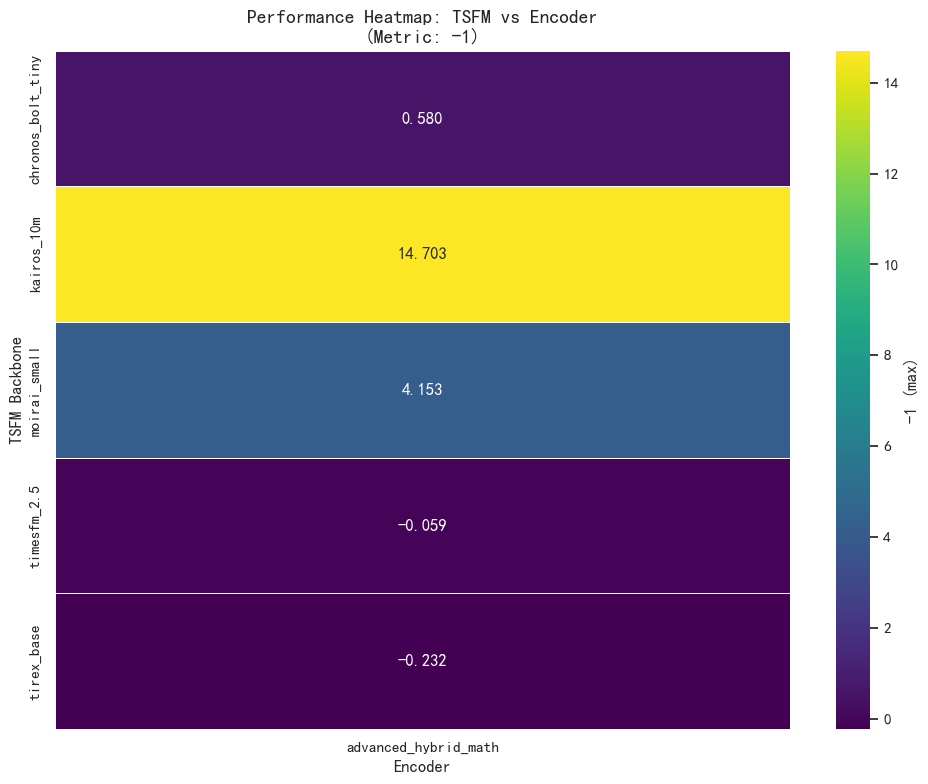

In [19]:
if not df_results.empty:
    # 1. 创建透视表
    # aggfunc='mean' 计算平均性能，也可以改为 'max' 查看该组合下的最佳性能
    pivot_table = df_results.pivot_table(
        index='TSFM', 
        columns='Encoder', 
        values='Performance', 
        aggfunc='mean' 
    )

    print(f"\n=== Performance Pivot Table ({TARGET_METRIC}) ===")
    display(pivot_table)

    # 2. 绘制热力图
    plt.figure(figsize=(10, 8))
    
    # 自动调整颜色映射范围
    vmin = df_results['Performance'].min()
    vmax = df_results['Performance'].max()
    
    heatmap = sns.heatmap(
        pivot_table, 
        annot=True,         # 显示数值
        fmt=".3f",          # 保留3位小数
        cmap="viridis",     # 颜色主题 (可选: 'coolwarm', 'RdBu_r', 'magma')
        linewidths=.5, 
        cbar_kws={'label': f'{TARGET_METRIC} ({METRIC_MODE})'}
    )
    
    plt.title(f'Performance Heatmap: TSFM vs Encoder\n(Metric: {TARGET_METRIC})', fontsize=14)
    plt.ylabel('TSFM Backbone', fontsize=12)
    plt.xlabel('Encoder', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("No data available to visualize.")

In [20]:
plot_quantile_trends_by_hash(root_dir=ROOT_DIR, hash_code=TARGET_HASH_FILTER, target_metric="sMAPE")

Scanning directory: results\dual_source_experiment_0331_V2
Filter enabled: Searching ONLY for experiments matching hash 'run_001_5b385438'...
🔍 成功找到匹配的实验，涵盖 3 个 Corrector 架构。开始绘图...

⚠️ Corrector [dual_fusion_V2] 下未找到符合 'sMAPE_Imp_Top' 格式的列，已跳过。
⚠️ Corrector [dual_latent_cross_attn] 下未找到符合 'sMAPE_Imp_Top' 格式的列，已跳过。
⚠️ Corrector [mean_retrieval] 下未找到符合 'sMAPE_Imp_Top' 格式的列，已跳过。
